In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"../Datos/data_accidentes.sqlite3")

In [2]:
accidentes = pd.read_sql("SELECT * FROM accidentes", conn, parse_dates=["TW"])
clima = pd.read_sql("SELECT * FROM clima", conn, parse_dates=["TW"])
raw = pd.read_sql("SELECT * FROM raw_accidentes", conn, parse_dates=["TW"])

conn.close()

In [4]:
print(accidentes.info())


<class 'pandas.DataFrame'>
RangeIndex: 120587 entries, 0 to 120586
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   TW       120587 non-null  datetime64[us]
 1   BARRIO   120587 non-null  str           
 2   Lat      120587 non-null  float64       
 3   Lon      120587 non-null  float64       
 4   Dia_sem  120587 non-null  str           
 5   Mes      120587 non-null  int64         
 6   Dia      120587 non-null  int64         
 7   Hora     120587 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(2)
memory usage: 7.4 MB
None


In [6]:
print(accidentes.isnull().sum())

TW         0
BARRIO     0
Lat        0
Lon        0
Dia_sem    0
Mes        0
Dia        0
Hora       0
dtype: int64


In [7]:
print(accidentes.duplicated().sum())

0


In [26]:
clima.head()




,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,1.02,NaN,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


In [10]:
print(clima.isnull().sum())


TW                           0
BARRIO                       0
summary                 548641
icon                    548641
precipIntensity         547401
precipProbability       547401
temperature                610
apparentTemperature        610
dewPoint                   305
humidity                   915
windSpeed                32793
windBearing            1032513
cloudCover                7950
uvIndex                   4280
visibility                4290
dtype: int64


In [11]:
nulos = clima.isnull().sum()
porcentaje = (nulos / len(clima) * 100).round(2)
pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje})

,Nulos,Porcentaje (%)
TW,0,0.00
BARRIO,0,0.00
summary,548641,6.87
icon,548641,6.87
precipIntensity,547401,6.85
precipProbability,547401,6.85
temperature,610,0.01
apparentTemperature,610,0.01
dewPoint,305,0.00
humidity,915,0.01


In [23]:
filas_summary_null = clima[clima["summary"].isnull()]

filas_summary_null.isnull().mean().sort_values(ascending=False) * 100

summary                100.000000
icon                   100.000000
precipIntensity         99.773987
precipProbability       99.773987
windBearing             20.990593
windSpeed                5.977133
cloudCover               1.449035
visibility               0.781932
uvIndex                  0.780109
humidity                 0.166776
temperature              0.111184
apparentTemperature      0.111184
dewPoint                 0.055592
TW                       0.000000
BARRIO                   0.000000
dtype: float64

In [22]:
mask = clima["windBearing"].isnull()
(clima.loc[mask].isnull().mean().sort_values(ascending=False) * 100).round(2)

windBearing            100.00
icon                    11.15
summary                 11.15
precipProbability       11.03
precipIntensity         11.03
windSpeed                3.18
cloudCover               0.27
visibility               0.27
uvIndex                  0.12
humidity                 0.09
temperature              0.06
apparentTemperature      0.06
dewPoint                 0.03
TW                       0.00
BARRIO                   0.00
dtype: float64

In [12]:
columnas=[]
for i in clima.columns:
    if i != "TW" and i != "BARRIO":
        columnas.append(i)
print(columnas )

antes = len(clima)
clima = clima.dropna(subset=columnas, how="all")
print(f"Filas eliminadas: {antes - len(clima)}")
print(f"Filas restantes: {len(clima)}")

['summary', 'icon', 'precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility']
Filas eliminadas: 0
Filas restantes: 7991780


In [9]:
mask = clima["windBearing"].isnull()
nulos = clima.loc[mask].isnull().sum()
porcentaje = (clima.loc[mask].isnull().mean() * 100).round(2)

pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje}).sort_values("Porcentaje (%)", ascending=False)

,Nulos,Porcentaje (%)
windBearing,1032513,100.00
icon,115163,11.15
summary,115163,11.15
precipProbability,113923,11.03
precipIntensity,113923,11.03
windSpeed,32793,3.18
cloudCover,2765,0.27
visibility,2765,0.27
uvIndex,1230,0.12
humidity,915,0.09


In [12]:
clima["summary"].unique()

<StringArray>
[                'Partly Cloudy',                         'Foggy',
                 'Mostly Cloudy',                         'Clear',
                      'Overcast',                             nan,
                       'Drizzle',                    'Light Rain',
                          'Rain',                    'Heavy Rain',
              'Possible Drizzle',           'Possible Light Rain',
       'Windy and Mostly Cloudy',       'Humid and Mostly Cloudy',
            'Humid and Overcast',       'Windy and Partly Cloudy',
                         'Windy',                'Rain and Windy',
                         'Humid', 'Possible Light Rain and Windy',
       'Humid and Partly Cloudy']
Length: 21, dtype: str

In [14]:
clima["icon"].unique()

<StringArray>
['partly-cloudy-night',                 'fog',   'partly-cloudy-day',
           'clear-day',              'cloudy',         'clear-night',
                   nan,                'rain',                'wind']
Length: 9, dtype: str

In [16]:
print(clima.duplicated().sum())

0


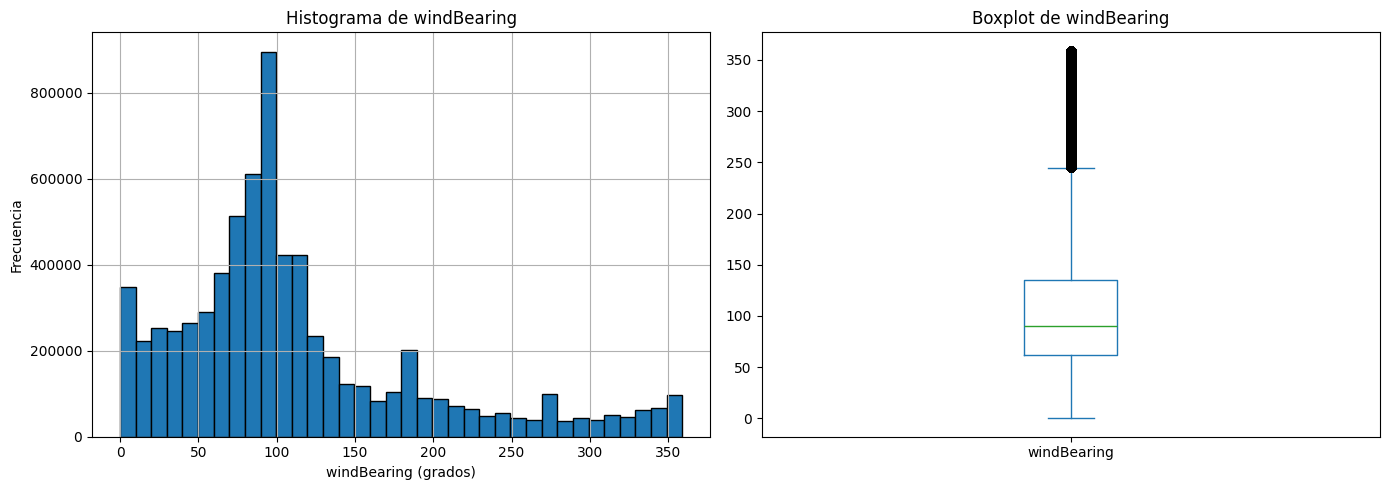

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clima["windBearing"].dropna().hist(bins=36, ax=axes[0], edgecolor="black")
axes[0].set_title("Histograma de windBearing")
axes[0].set_xlabel("windBearing (grados)")
axes[0].set_ylabel("Frecuencia")

clima["windBearing"].dropna().plot.box(ax=axes[1])
axes[1].set_title("Boxplot de windBearing")

plt.tight_layout()
plt.show()

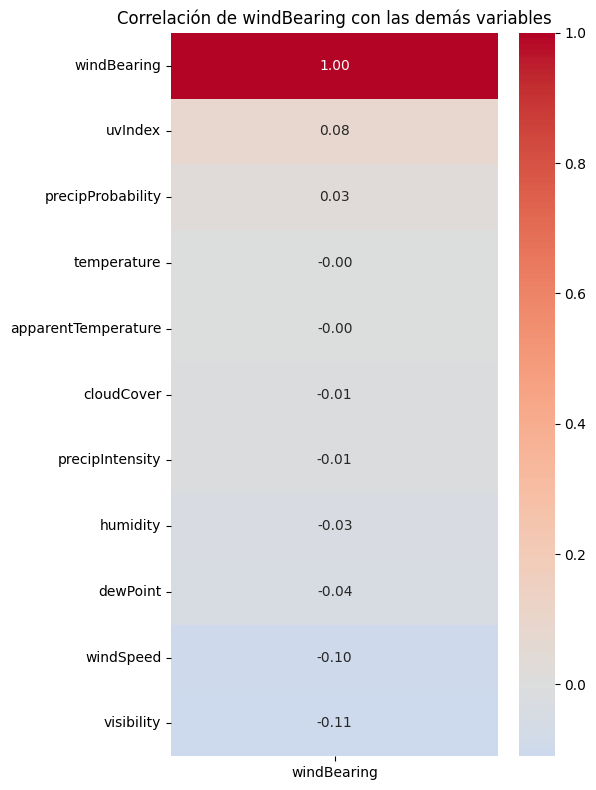

In [14]:
import seaborn as sns

numericas = clima.select_dtypes(include="number")
corr = numericas.corr()[["windBearing"]].sort_values("windBearing", ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación de windBearing con las demás variables")
plt.tight_layout()
plt.show()

In [17]:
print(raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 125122 entries, 0 to 125121
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Lon            125122 non-null  float64       
 1   Lat            125122 non-null  float64       
 2   OBJECTID       125122 non-null  int64         
 3   RADICADO       125117 non-null  str           
 4   HORA           125122 non-null  str           
 5   Dia_sem        125122 non-null  str           
 6   PERIODO        125122 non-null  int64         
 7   CLASE          125122 non-null  str           
 8   DIRECCION      125122 non-null  str           
 9   DIRECCION_ENC  125122 non-null  str           
 10  CBML           125122 non-null  str           
 11  TIPO_GEOCOD    125122 non-null  str           
 12  GRAVEDAD       125122 non-null  str           
 13  BARRIO         125122 non-null  str           
 14  COMUNA         125122 non-null  str           
 15  DISENO     

In [18]:
print(raw.describe())

                 Lon            Lat       OBJECTID        PERIODO  \
count  125122.000000  125122.000000  125122.000000  125122.000000   
mean      -75.577059       6.250224  628445.870686    2017.999169   
min       -75.701661       6.166846  503352.000000    2017.000000   
25%       -75.586578       6.231896  537442.250000    2017.000000   
50%       -75.574821       6.250107  665085.500000    2018.000000   
75%       -75.565207       6.271176  720792.750000    2019.000000   
max       -75.480742       6.368394  758669.000000    2019.000000   
std         0.019038       0.028559   91283.479422       0.823582   

                 Mes            Dia       Hora_num                          TW  
count  125122.000000  125122.000000  125122.000000                      125122  
mean        6.665063      15.623735      13.262728  2018-07-06 09:11:47.357619  
min         1.000000       1.000000       0.000000         2017-01-01 00:00:00  
25%         4.000000       8.000000       9.000000    

In [19]:
nulos = raw.isnull().sum()
porcentaje = (nulos / len(clima) * 100).round(2)

pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje})

,Nulos,Porcentaje (%)
Lon,0,0.00
Lat,0,0.00
OBJECTID,0,0.00
RADICADO,5,0.00
HORA,0,0.00
Dia_sem,0,0.00
PERIODO,0,0.00
CLASE,0,0.00
DIRECCION,0,0.00
DIRECCION_ENC,0,0.00


In [3]:

import os

os.makedirs("Datos/csv", exist_ok=True)
accidentes.to_csv("Datos/csv/accidentes.csv", index=False, encoding="utf-8-sig")
clima.to_csv("Datos/csv/clima.csv", index=False, encoding="utf-8-sig")
raw.to_csv("Datos/csv/raw_accidentes.csv", index=False, encoding="utf-8-sig")

print("✅ Archivos CSV guardados correctamente")

✅ Archivos CSV guardados correctamente
